In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           mean_absolute_error, mean_squared_error, r2_score,
                           confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('marketing_campaign.csv', sep='\t')  # Using tab separator

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2240, 29)

First 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  

In [8]:
# Data Preprocessing Class
class DataPreprocessor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.feature_columns = None
        
    def clean_data(self, df):
        """Initial data cleaning"""
        df_clean = df.copy()
        
        # Remove outliers in Income (replace with median)
        df_clean['Income'] = df_clean['Income'].replace(' ', np.nan)
        df_clean['Income'] = pd.to_numeric(df_clean['Income'], errors='coerce')
        
        # Fix absurd birth years (e.g., 1900, 1893) - replace with median
        median_year = df_clean['Year_Birth'].median()
        df_clean['Year_Birth'] = df_clean['Year_Birth'].apply(
            lambda x: median_year if x < 1900 or x > 2020 else x
        )
        
        # Calculate Age
        df_clean['Age'] = 2024 - df_clean['Year_Birth']
        
        # Calculate total children
        df_clean['Total_Children'] = df_clean['Kidhome'] + df_clean['Teenhome']
        
        # Calculate total spending on all products
        spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
        df_clean['Total_Spending'] = df_clean[spending_cols].sum(axis=1)
        
        # Calculate total purchases
        purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
        df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)
        
        # Calculate average spend per purchase
        df_clean['Avg_Spend_Per_Purchase'] = df_clean['Total_Spending'] / (df_clean['Total_Purchases'] + 1)
        
        # Calculate acceptance rate of campaigns
        campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
        df_clean['Campaign_Acceptance_Rate'] = df_clean[campaign_cols].mean(axis=1)
        
        # Calculate total accepted campaigns
        df_clean['Total_Accepted_Campaigns'] = df_clean[campaign_cols].sum(axis=1)
        
        # Create feature: days since customer enrolled
        df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%d-%m-%Y')
        df_clean['Customer_Tenure_Days'] = (pd.Timestamp('2014-12-31') - df_clean['Dt_Customer']).dt.days
        
        # Create engagement score
        df_clean['Engagement_Score'] = (
            df_clean['NumWebVisitsMonth'] * 0.3 +
            df_clean['NumWebPurchases'] * 0.4 +
            df_clean['NumDealsPurchases'] * 0.3
        )
        
        return df_clean
    
    def preprocess(self, df, target_col, is_training=True):
        """Complete preprocessing pipeline"""
        df_processed = df.copy()
        
        # Select features
        feature_cols = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Total_Children',
        'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
        'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
        'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending',
        'Total_Purchases', 'Avg_Spend_Per_Purchase', 
        'Campaign_Acceptance_Rate', 'Total_Accepted_Campaigns',
            'Customer_Tenure_Days', 'Engagement_Score', 'Complain'
        ]
        
        # Add education and marital status as categorical
        categorical_cols = ['Education', 'Marital_Status']
        
        for col in categorical_cols:
            if col in df_processed.columns:
                feature_cols.append(col)
        
        # Filter existing columns
        feature_cols = [col for col in feature_cols if col in df_processed.columns]
        
        # Separate features and target
        if target_col in df_processed.columns:
            X = df_processed[feature_cols].copy()
            y = df_processed[target_col].copy() if is_training else None
        else:
            X = df_processed[feature_cols].copy()
            y = None
        
        # Handle missing values
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        categorical_cols_present = [col for col in categorical_cols if col in X.columns]
        
        # Impute numeric columns with median
        numeric_imputer = SimpleImputer(strategy='median')
        X[numeric_cols] = numeric_imputer.fit_transform(X[numeric_cols])
        
        # Impute categorical columns with mode
        if categorical_cols_present:
            categorical_imputer = SimpleImputer(strategy='most_frequent')
            X[categorical_cols_present] = categorical_imputer.fit_transform(X[categorical_cols_present])
        
        # Encode categorical variables
        for col in categorical_cols_present:
            if is_training:
                self.label_encoders[col] = LabelEncoder()
                X[col] = self.label_encoders[col].fit_transform(X[col])
            else:
                if col in self.label_encoders:
                    X[col] = self.label_encoders[col].transform(X[col])
        
        # Scale numeric features
        self.feature_columns = X.columns
        if is_training:
            X_scaled = self.scaler.fit_transform(X)
        else:
            X_scaled = self.scaler.transform(X)
        
        X_scaled = pd.DataFrame(X_scaled, columns=self.feature_columns)
        
        return X_scaled, y

# Apply preprocessing
preprocessor = DataPreprocessor()
df_clean = preprocessor.clean_data(df)

# Check Response distribution (purchase = 1)
print("\nResponse Distribution:")
print(df_clean['Response'].value_counts())
print(f"Response Rate: {df_clean['Response'].mean()*100:.2f}%")

# Preprocess for classification
X_class, y_class = preprocessor.preprocess(df_clean, 'Response', is_training=True)

print(f"\nPreprocessed Data Shape: {X_class.shape}")
print(f"Features: {list(X_class.columns)}")


Response Distribution:
Response
0    1906
1     334
Name: count, dtype: int64
Response Rate: 14.91%

Preprocessed Data Shape: (2240, 27)
Features: ['Age', 'Income', 'Kidhome', 'Teenhome', 'Total_Children', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Spending', 'Total_Purchases', 'Avg_Spend_Per_Purchase', 'Campaign_Acceptance_Rate', 'Total_Accepted_Campaigns', 'Customer_Tenure_Days', 'Engagement_Score', 'Complain', 'Education', 'Marital_Status']


Exploratory Data Analysis (EDA)

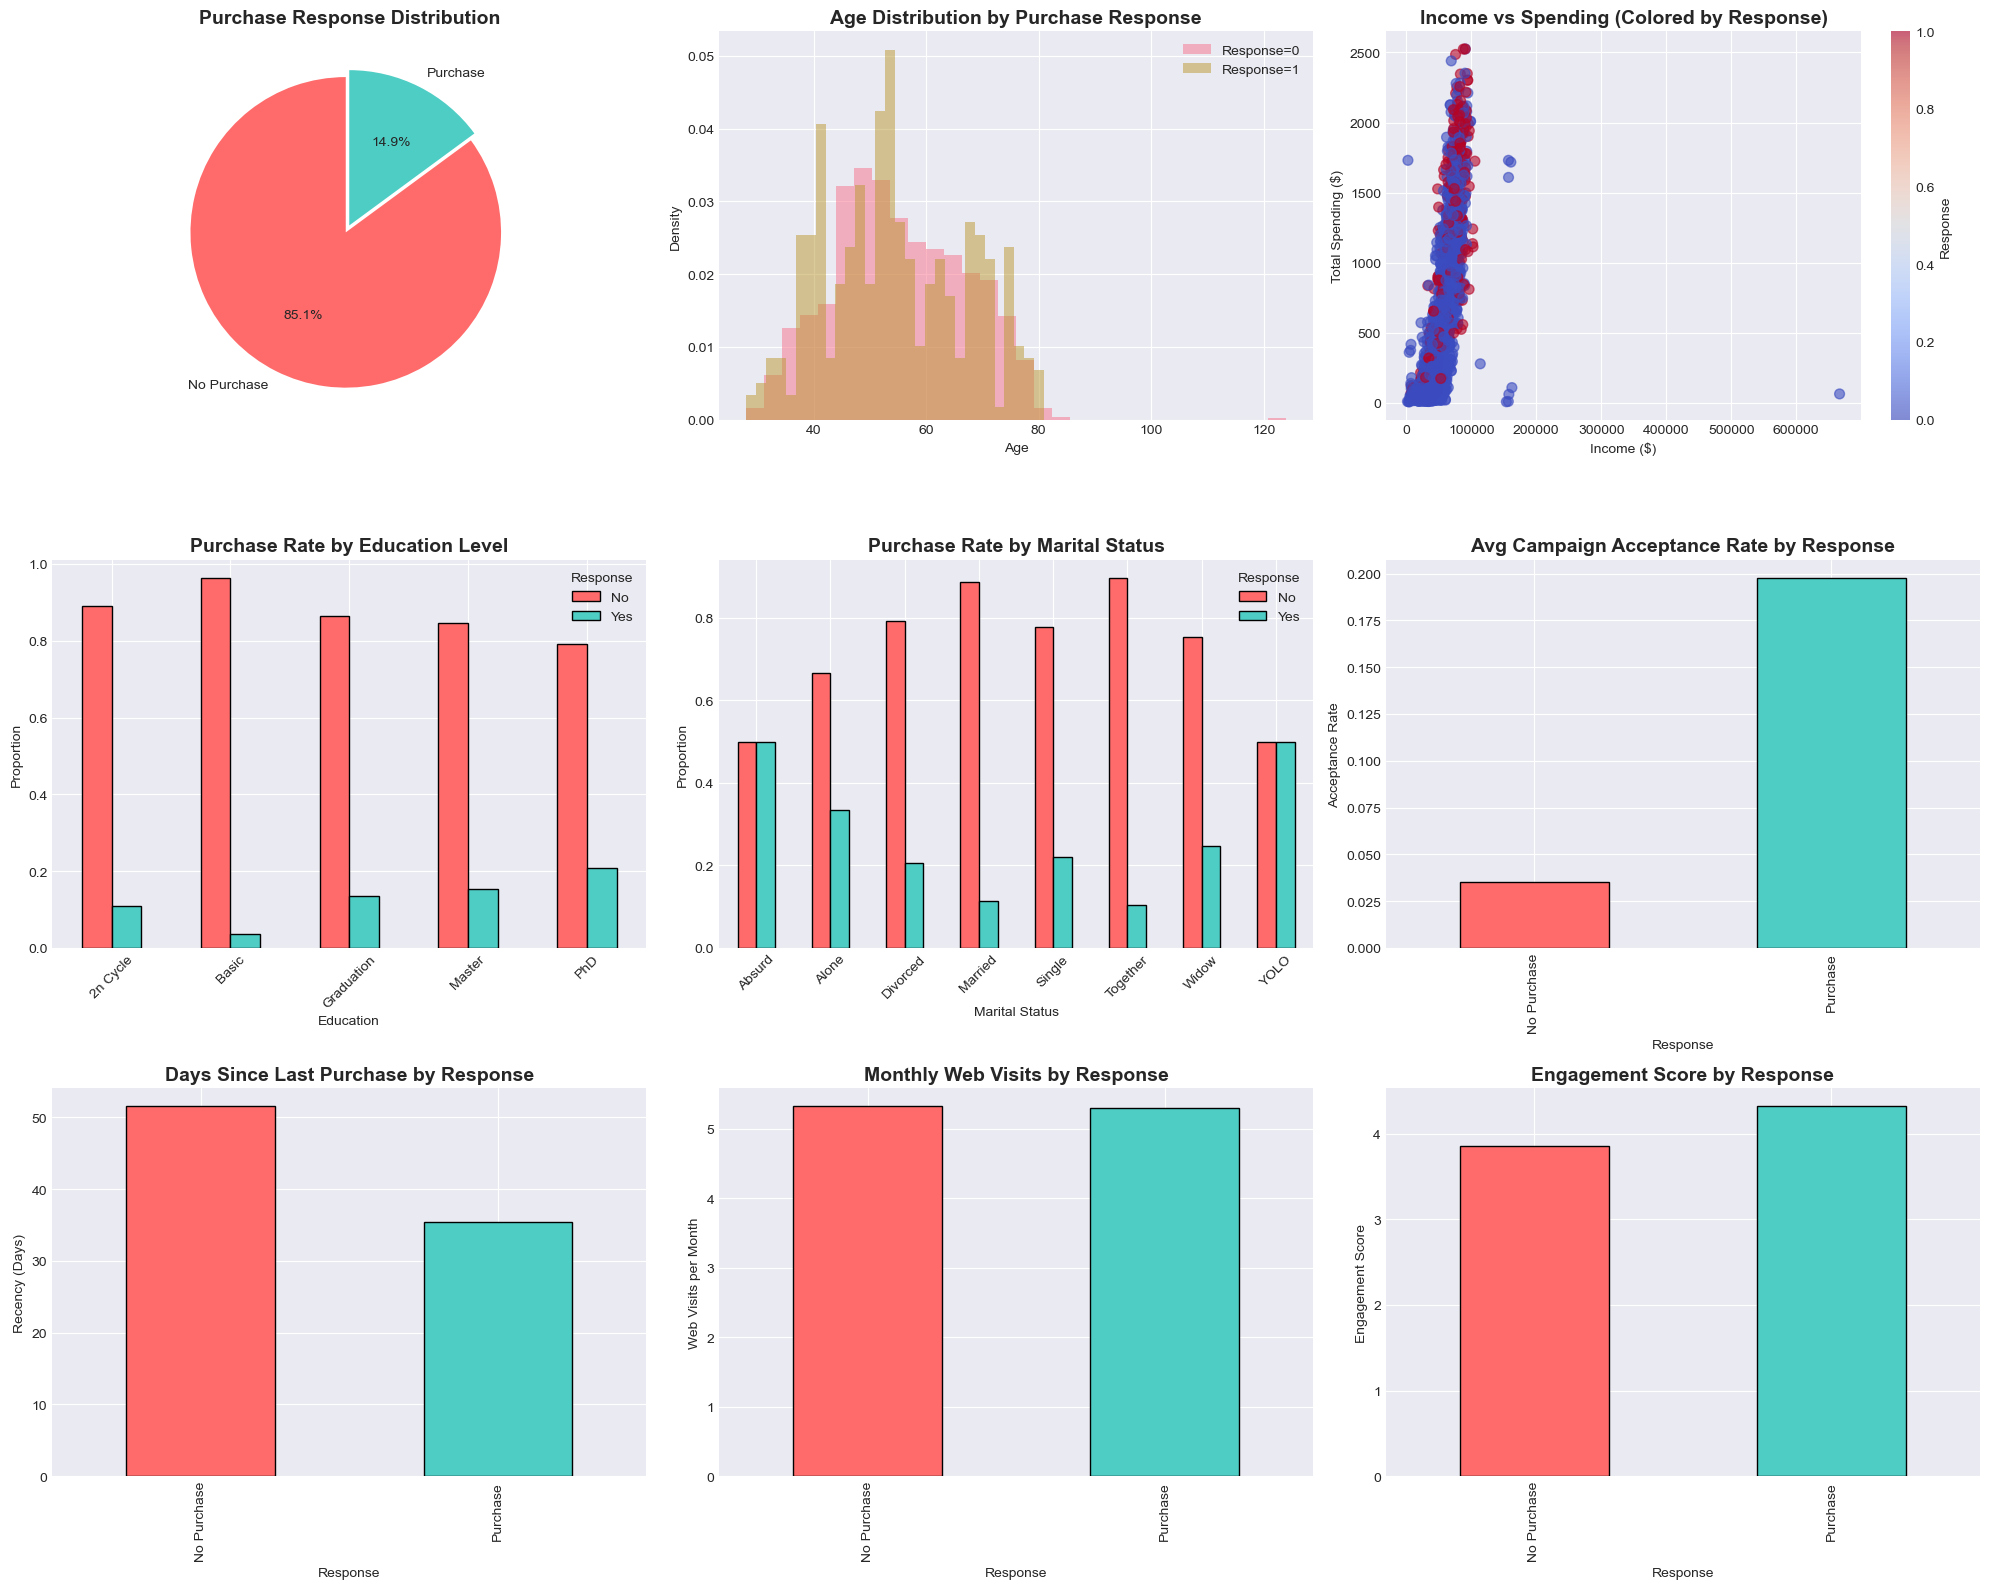


KEY INSIGHTS FROM EDA

📊 Overall Statistics:
  • Total Customers: 2,240
  • Purchase Rate: 14.91%
  • Average Age: 55.1 years
  • Average Income: $52,247
  • Average Total Spending: $605.80

💰 Purchasers vs Non-Purchasers:
  • Avg Income (Purchasers): $60,210
  • Avg Income (Non-Purchasers): $50,839
  • Avg Spending (Purchasers): $987.39
  • Avg Spending (Non-Purchasers): $538.93
  • Avg Web Visits (Purchasers): 5.3
  • Avg Web Visits (Non-Purchasers): 5.3


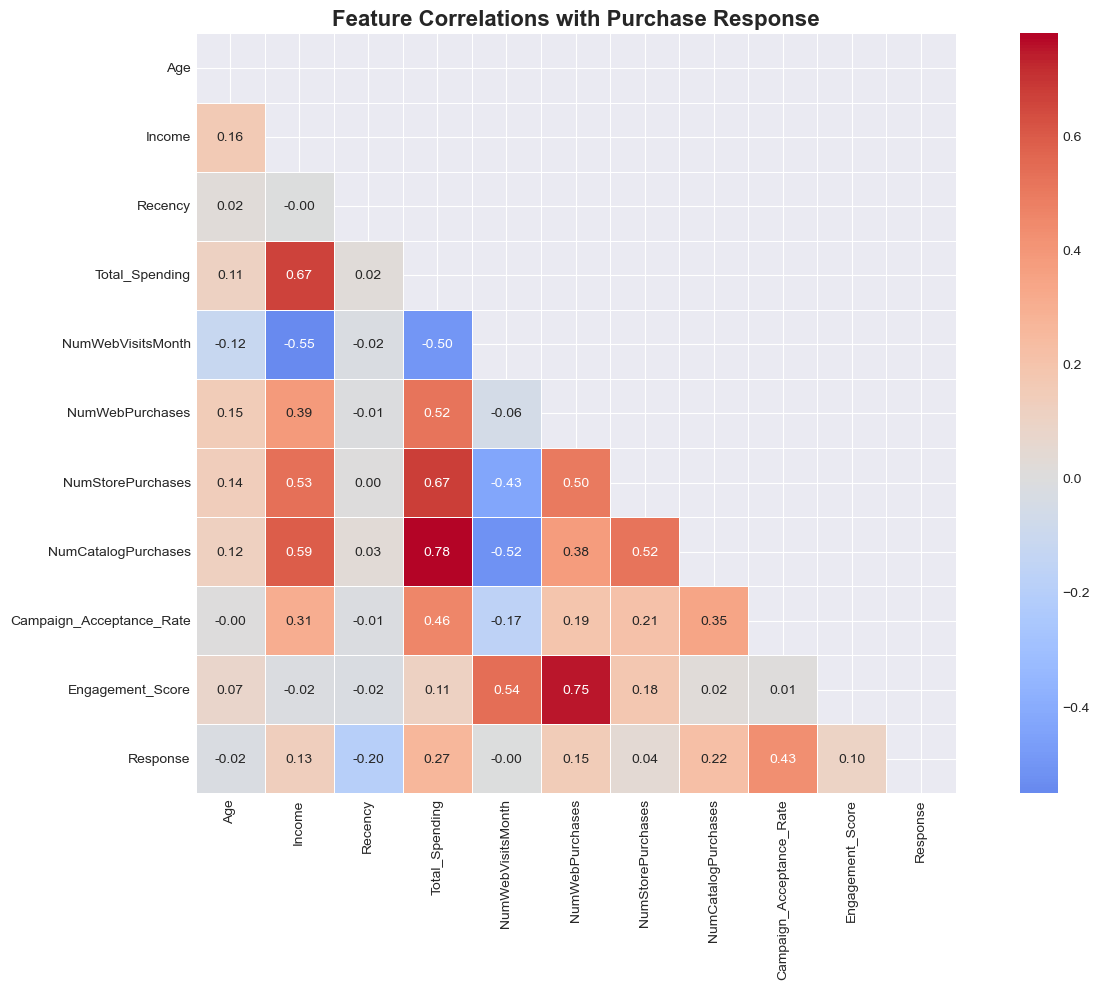

In [10]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create comprehensive EDA
fig = plt.figure(figsize=(20, 16))

# 1. Response Distribution
ax1 = fig.add_subplot(3, 3, 1)
response_counts = df_clean['Response'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
ax1.pie(response_counts, labels=['No Purchase', 'Purchase'], autopct='%1.1f%%', 
        colors=colors, explode=(0.05, 0), startangle=90)
ax1.set_title('Purchase Response Distribution', fontsize=14, fontweight='bold')

# 2. Age Distribution by Response
ax2 = fig.add_subplot(3, 3, 2)
for response in [0, 1]:
    data = df_clean[df_clean['Response'] == response]['Age']
    ax2.hist(data, bins=30, alpha=0.5, label=f'Response={response}', density=True)
ax2.set_xlabel('Age')
ax2.set_ylabel('Density')
ax2.set_title('Age Distribution by Purchase Response', fontsize=14, fontweight='bold')
ax2.legend()

# 3. Income vs Total Spending
ax3 = fig.add_subplot(3, 3, 3)
scatter = ax3.scatter(df_clean['Income'], df_clean['Total_Spending'], 
c=df_clean['Response'], cmap='coolwarm', alpha=0.6, s=50
)
ax3.set_xlabel('Income ($)')
ax3.set_ylabel('Total Spending ($)')
ax3.set_title('Income vs Spending (Colored by Response)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Response')

# 4. Education Level Impact
ax4 = fig.add_subplot(3, 3, 4)
education_response = pd.crosstab(df_clean['Education'], df_clean['Response'], normalize='index')
education_response.plot(kind='bar', ax=ax4, color=colors, edgecolor='black')
ax4.set_title('Purchase Rate by Education Level', fontsize=14, fontweight='bold')
ax4.set_xlabel('Education')
ax4.set_ylabel('Proportion')
ax4.legend(title='Response', labels=['No', 'Yes'])
ax4.tick_params(axis='x', rotation=45)

# 5. Marital Status Impact
ax5 = fig.add_subplot(3, 3, 5)
marital_response = pd.crosstab(df_clean['Marital_Status'], df_clean['Response'], normalize='index')
marital_response.plot(kind='bar', ax=ax5, color=colors, edgecolor='black')
ax5.set_title('Purchase Rate by Marital Status', fontsize=14, fontweight='bold')
ax5.set_xlabel('Marital Status')
ax5.set_ylabel('Proportion')
ax5.legend(title='Response', labels=['No', 'Yes'])
ax5.tick_params(axis='x', rotation=45)

# 6. Campaign Acceptance Impact
ax6 = fig.add_subplot(3, 3, 6)
df_clean.groupby('Response')['Campaign_Acceptance_Rate'].mean().plot(
    kind='bar', ax=ax6, color=colors, edgecolor='black')
ax6.set_title('Avg Campaign Acceptance Rate by Response', fontsize=14, fontweight='bold')
ax6.set_xlabel('Response')
ax6.set_ylabel('Acceptance Rate')
ax6.set_xticklabels(['No Purchase', 'Purchase'])

# 7. Recency Analysis
ax7 = fig.add_subplot(3, 3, 7)
df_clean.groupby('Response')['Recency'].mean().plot(
    kind='bar', ax=ax7, color=colors, edgecolor='black')
ax7.set_title('Days Since Last Purchase by Response', fontsize=14, fontweight='bold')
ax7.set_xlabel('Response')
ax7.set_ylabel('Recency (Days)')
ax7.set_xticklabels(['No Purchase', 'Purchase'])

# 8. Web Visits Analysis
ax8 = fig.add_subplot(3, 3, 8)
df_clean.groupby('Response')['NumWebVisitsMonth'].mean().plot(
    kind='bar', ax=ax8, color=colors, edgecolor='black')
ax8.set_title('Monthly Web Visits by Response', fontsize=14, fontweight='bold')
ax8.set_xlabel('Response')
ax8.set_ylabel('Web Visits per Month')
ax8.set_xticklabels(['No Purchase', 'Purchase'])

# 9. Engagement Score
ax9 = fig.add_subplot(3, 3, 9)
df_clean.groupby('Response')['Engagement_Score'].mean().plot(
    kind='bar', ax=ax9, color=colors, edgecolor='black')
ax9.set_title('Engagement Score by Response', fontsize=14, fontweight='bold')
ax9.set_xlabel('Response')
ax9.set_ylabel('Engagement Score')
ax9.set_xticklabels(['No Purchase', 'Purchase'])

plt.tight_layout()
plt.show()

# Additional Insights
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print(f"\n📊 Overall Statistics:")
print(f"  • Total Customers: {len(df_clean):,}")
print(f"  • Purchase Rate: {df_clean['Response'].mean()*100:.2f}%")
print(f"  • Average Age: {df_clean['Age'].mean():.1f} years")
print(f"  • Average Income: ${df_clean['Income'].mean():,.0f}")
print(f"  • Average Total Spending: ${df_clean['Total_Spending'].mean():.2f}")

print(f"\n💰 Purchasers vs Non-Purchasers:")
purchasers = df_clean[df_clean['Response'] == 1]
non_purchasers = df_clean[df_clean['Response'] == 0]

print(f"  • Avg Income (Purchasers): ${purchasers['Income'].mean():,.0f}")
print(f"  • Avg Income (Non-Purchasers): ${non_purchasers['Income'].mean():,.0f}")
print(f"  • Avg Spending (Purchasers): ${purchasers['Total_Spending'].mean():.2f}")
print(f"  • Avg Spending (Non-Purchasers): ${non_purchasers['Total_Spending'].mean():.2f}")
print(f"  • Avg Web Visits (Purchasers): {purchasers['NumWebVisitsMonth'].mean():.1f}")
print(f"  • Avg Web Visits (Non-Purchasers): {non_purchasers['NumWebVisitsMonth'].mean():.1f}")

# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_features = ['Age', 'Income', 'Recency', 'Total_Spending', 'NumWebVisitsMonth',
'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases',
'Campaign_Acceptance_Rate', 'Engagement_Score', 'Response'
]
corr_matrix = df_clean[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlations with Purchase Response', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Model Building - Classification

In [11]:
class PurchasePredictor:
    def __init__(self):
        self.classification_models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
            'Naive Bayes': GaussianNB(),
            'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, 
                                    eval_metric='logloss', scale_pos_weight=3)
        }
        
        self.regression_models = {
            'Linear Regression': LinearRegression(),
            'Gradient Boosting': GradientBoostingRegressor(random_state=42)
        }
        
        self.best_classifier = None
        self.best_regressor = None
        
    def train_classification(self, X, y):
        """Train all classification models"""
        # Split data (stratified for imbalanced dataset)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        results = {}
        
        for name, model in self.classification_models.items():
            print(f"\n{'='*50}")
            print(f"Training {name}...")
            print('='*50)
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
            
            results[name] = {
                'model': model,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'y_test': y_test,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }
            
            print(f"\n📈 Performance Metrics:")
            print(f"  • Accuracy:  {accuracy:.4f}")
            print(f"  • Precision: {precision:.4f}")
            print(f"  • Recall:    {recall:.4f}")
            print(f"  • F1-Score:  {f1:.4f}")
            print(f"  • CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
            
            # Classification Report
            print(f"\n📋 Classification Report:")
            print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))
        
        # Select best model based on F1-score
        best_name = max(results, key=lambda x: results[x]['f1'])
        self.best_classifier = results[best_name]['model']
        print(f"\n{'='*50}")
        print(f"✓ Best Classifier: {best_name} (F1-Score: {results[best_name]['f1']:.4f})")
        print('='*50)
        
        return results
    
    def train_regression(self, X, y):
        """Train regression models on purchasers only"""
        # Filter only customers who made a purchase
        purchase_mask = y == 1
        X_purchasers = X[purchase_mask]
        
        # For regression, we predict total spending
        y_spending = df_clean.loc[purchase_mask, 'Total_Spending'].values
        
        if len(X_purchasers) == 0:
            print("No purchasers found for regression training!")
            return None
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_purchasers, y_spending, test_size=0.2, random_state=42
        )
        
        results = {}
        
        for name, model in self.regression_models.items():
            print(f"\n{'='*50}")
            print(f"Training {name} for Spending Prediction...")
            print('='*50)
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
            
            results[name] = {
                'model': model,
                'mae': mae,
                'rmse': rmse,
                'r2': r2,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'y_test': y_test,
                'y_pred': y_pred
            }
            
            print(f"\n📈 Performance Metrics:")
            print(f"  • MAE:  ${mae:.2f}")
            print(f"  • RMSE: ${rmse:.2f}")
            print(f"  • R² Score: {r2:.4f}")
            print(f"  • CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        
        # Select best model based on R²
        best_name = max(results, key=lambda x: results[x]['r2'])
        self.best_regressor = results[best_name]['model']
        print(f"\n{'='*50}")
        print(f"✓ Best Regressor: {best_name} (R² Score: {results[best_name]['r2']:.4f})")
        print('='*50)
        
        return results

# Train models
predictor = PurchasePredictor()
classification_results = predictor.train_classification(X_class, y_class)

# For regression, we need the original data with total spending
X_reg_full, y_reg_full = preprocessor.preprocess(df_clean, 'Response', is_training=True)
regression_results = predictor.train_regression(X_reg_full, y_reg_full)


Training Logistic Regression...

📈 Performance Metrics:
  • Accuracy:  0.8259
  • Precision: 0.4505
  • Recall:    0.7463
  • F1-Score:  0.5618
  • CV F1-Score: 0.5424 (+/- 0.0268)

📋 Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.95      0.84      0.89       381
    Purchase       0.45      0.75      0.56        67

    accuracy                           0.83       448
   macro avg       0.70      0.79      0.73       448
weighted avg       0.87      0.83      0.84       448


Training Naive Bayes...

📈 Performance Metrics:
  • Accuracy:  0.7701
  • Precision: 0.3448
  • Recall:    0.5970
  • F1-Score:  0.4372
  • CV F1-Score: 0.4296 (+/- 0.0390)

📋 Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.92      0.80      0.86       381
    Purchase       0.34      0.60      0.44        67

    accuracy                           0.77       448
   macro avg       0.63      0.70      0.65    

Hyperparameter Tuning

In [13]:
def tune_xgboost(X, y):
    """Hyperparameter tuning for XGBoost"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    # Base model
    xgb = XGBClassifier(random_state=42, use_label_encoder=False, 
    eval_metric='logloss', scale_pos_weight=3
    )
    
    # Grid search
    grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='f1', 
    n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"\n{'='*50}")
    print("HYPERPARAMETER TUNING RESULTS")
    print('='*50)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")
    
    # Evaluate on test set
    y_pred = grid_search.predict(X_test)
    final_f1 = f1_score(y_test, y_pred)
    final_precision = precision_score(y_test, y_pred)
    final_recall = recall_score(y_test, y_pred)
    
    print(f"\nTest Set Performance with Best Parameters:")
    print(f"  • F1-Score: {final_f1:.4f}")
    print(f"  • Precision: {final_precision:.4f}")
    print(f"  • Recall: {final_recall:.4f}")
    
    return grid_search.best_estimator_

# Tune XGBoost (best performing model)
tuned_xgb = tune_xgboost(X_class, y_class)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

HYPERPARAMETER TUNING RESULTS
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1-Score: 0.6089

Test Set Performance with Best Parameters:
  • F1-Score: 0.5303
  • Precision: 0.5385
  • Recall: 0.5224


Feature Importance and Visualizations

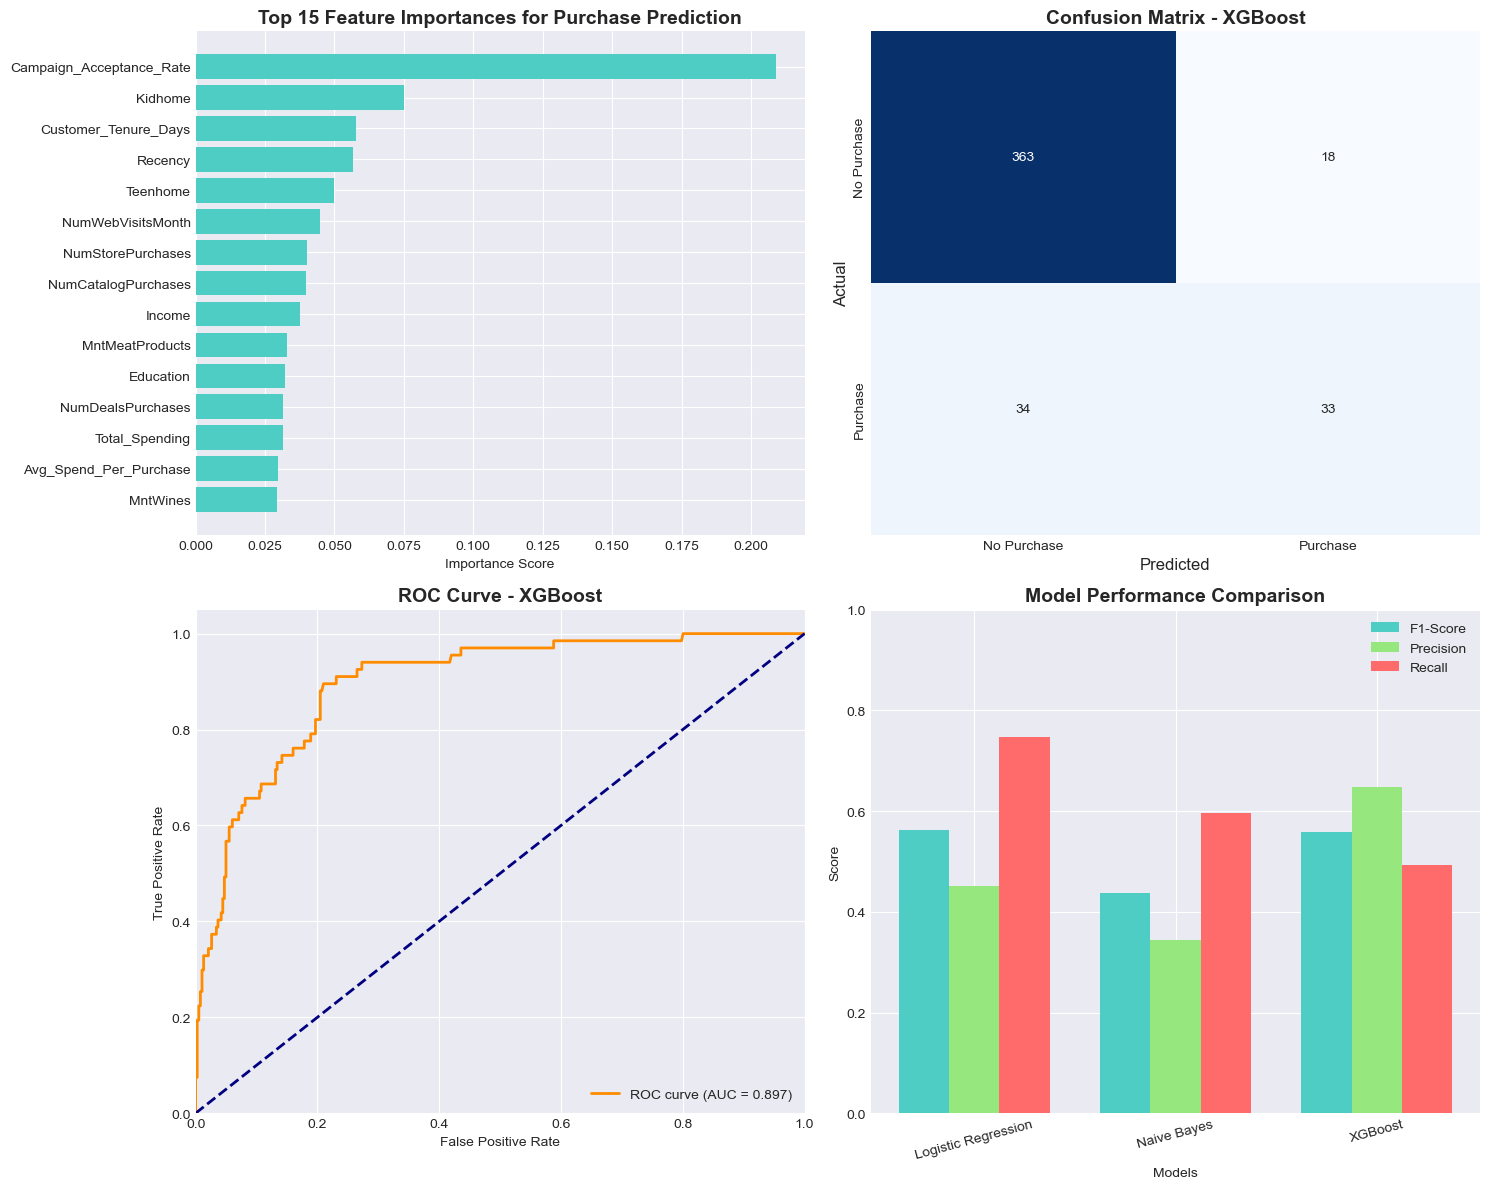


TOP FACTORS INFLUENCING PURCHASE DECISION
1. Campaign_Acceptance_Rate: 20.9% importance
2. Kidhome: 7.5% importance
3. Customer_Tenure_Days: 5.8% importance
4. Recency: 5.7% importance
5. Teenhome: 5.0% importance
6. NumWebVisitsMonth: 4.5% importance
7. NumStorePurchases: 4.0% importance
8. NumCatalogPurchases: 4.0% importance
9. Income: 3.8% importance
10. MntMeatProducts: 3.3% importance


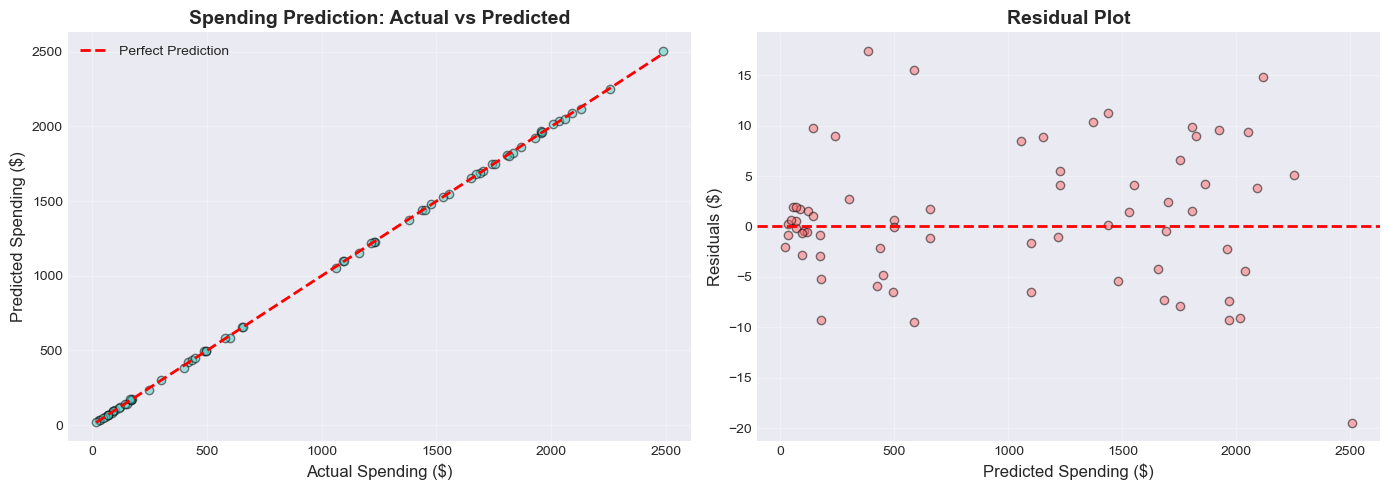


REGRESSION MODEL PERFORMANCE (Spending Prediction)

Linear Regression:
  • MAE:  $0.00
  • RMSE: $0.00
  • R²:   1.0000

Gradient Boosting:
  • MAE:  $5.05
  • RMSE: $6.73
  • R²:   0.9999


In [14]:
# Get the best model (XGBoost)
best_model = classification_results['XGBoost']['model']

# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X_class.columns
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot feature importance
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Feature Importance
    top_features = feature_importance_df.head(15)
    axes[0,0].barh(range(len(top_features)), top_features['importance'], color='#4ecdc4')
    axes[0,0].set_yticks(range(len(top_features)))
    axes[0,0].set_yticklabels(top_features['feature'])
    axes[0,0].set_xlabel('Importance Score')
    axes[0,0].set_title('Top 15 Feature Importances for Purchase Prediction', fontsize=14, fontweight='bold')
    axes[0,0].invert_yaxis()
    
    # 2. Confusion Matrix for Best Model
    best_result = classification_results['XGBoost']
    cm = confusion_matrix(best_result['y_test'], best_result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1], cbar=False)
    axes[0,1].set_xlabel('Predicted', fontsize=12)
    axes[0,1].set_ylabel('Actual', fontsize=12)
    axes[0,1].set_title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
    axes[0,1].set_xticklabels(['No Purchase', 'Purchase'])
    axes[0,1].set_yticklabels(['No Purchase', 'Purchase'])
    
    # 3. ROC Curve
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(best_result['y_test'], best_result['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    
    axes[1,0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1,0].set_xlim([0.0, 1.0])
    axes[1,0].set_ylim([0.0, 1.05])
    axes[1,0].set_xlabel('False Positive Rate')
    axes[1,0].set_ylabel('True Positive Rate')
    axes[1,0].set_title('ROC Curve - XGBoost', fontsize=14, fontweight='bold')
    axes[1,0].legend(loc="lower right")
    
    # 4. Model Comparison
    model_names = list(classification_results.keys())
    f1_scores = [classification_results[name]['f1'] for name in model_names]
    precision_scores = [classification_results[name]['precision'] for name in model_names]
    recall_scores = [classification_results[name]['recall'] for name in model_names]
    
    x = np.arange(len(model_names))
    width = 0.25
    
    axes[1,1].bar(x - width, f1_scores, width, label='F1-Score', color='#4ecdc4')
    axes[1,1].bar(x, precision_scores, width, label='Precision', color='#95e77e')
    axes[1,1].bar(x + width, recall_scores, width, label='Recall', color='#ff6b6b')
    axes[1,1].set_xlabel('Models')
    axes[1,1].set_ylabel('Score')
    axes[1,1].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(model_names, rotation=15)
    axes[1,1].legend()
    axes[1,1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print("\n" + "="*60)
    print("TOP FACTORS INFLUENCING PURCHASE DECISION")
    print("="*60)
    for i, (feature, importance) in enumerate(zip(top_features['feature'][:10], top_features['importance'][:10])):
        print(f"{i+1}. {feature}: {importance*100:.1f}% importance")

# Regression Results Visualization
if regression_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Predicted vs Actual
    reg_best = regression_results['Gradient Boosting']
    axes[0].scatter(reg_best['y_test'], reg_best['y_pred'], alpha=0.5, color='#4ecdc4', edgecolor='black')
    axes[0].plot([reg_best['y_test'].min(), reg_best['y_test'].max()], 
                [reg_best['y_test'].min(), reg_best['y_test'].max()], 
                'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Spending ($)', fontsize=12)
    axes[0].set_ylabel('Predicted Spending ($)', fontsize=12)
    axes[0].set_title('Spending Prediction: Actual vs Predicted', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residuals Plot
    residuals = reg_best['y_test'] - reg_best['y_pred']
    axes[1].scatter(reg_best['y_pred'], residuals, alpha=0.5, color='#ff6b6b', edgecolor='black')
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Spending ($)', fontsize=12)
    axes[1].set_ylabel('Residuals ($)', fontsize=12)
    axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Regression metrics summary
    print("\n" + "="*60)
    print("REGRESSION MODEL PERFORMANCE (Spending Prediction)")
    print("="*60)
    for name, results in regression_results.items():
        print(f"\n{name}:")
        print(f"  • MAE:  ${results['mae']:.2f}")
        print(f"  • RMSE: ${results['rmse']:.2f}")
        print(f"  • R²:   {results['r2']:.4f}")

Business Insights and Recommendations

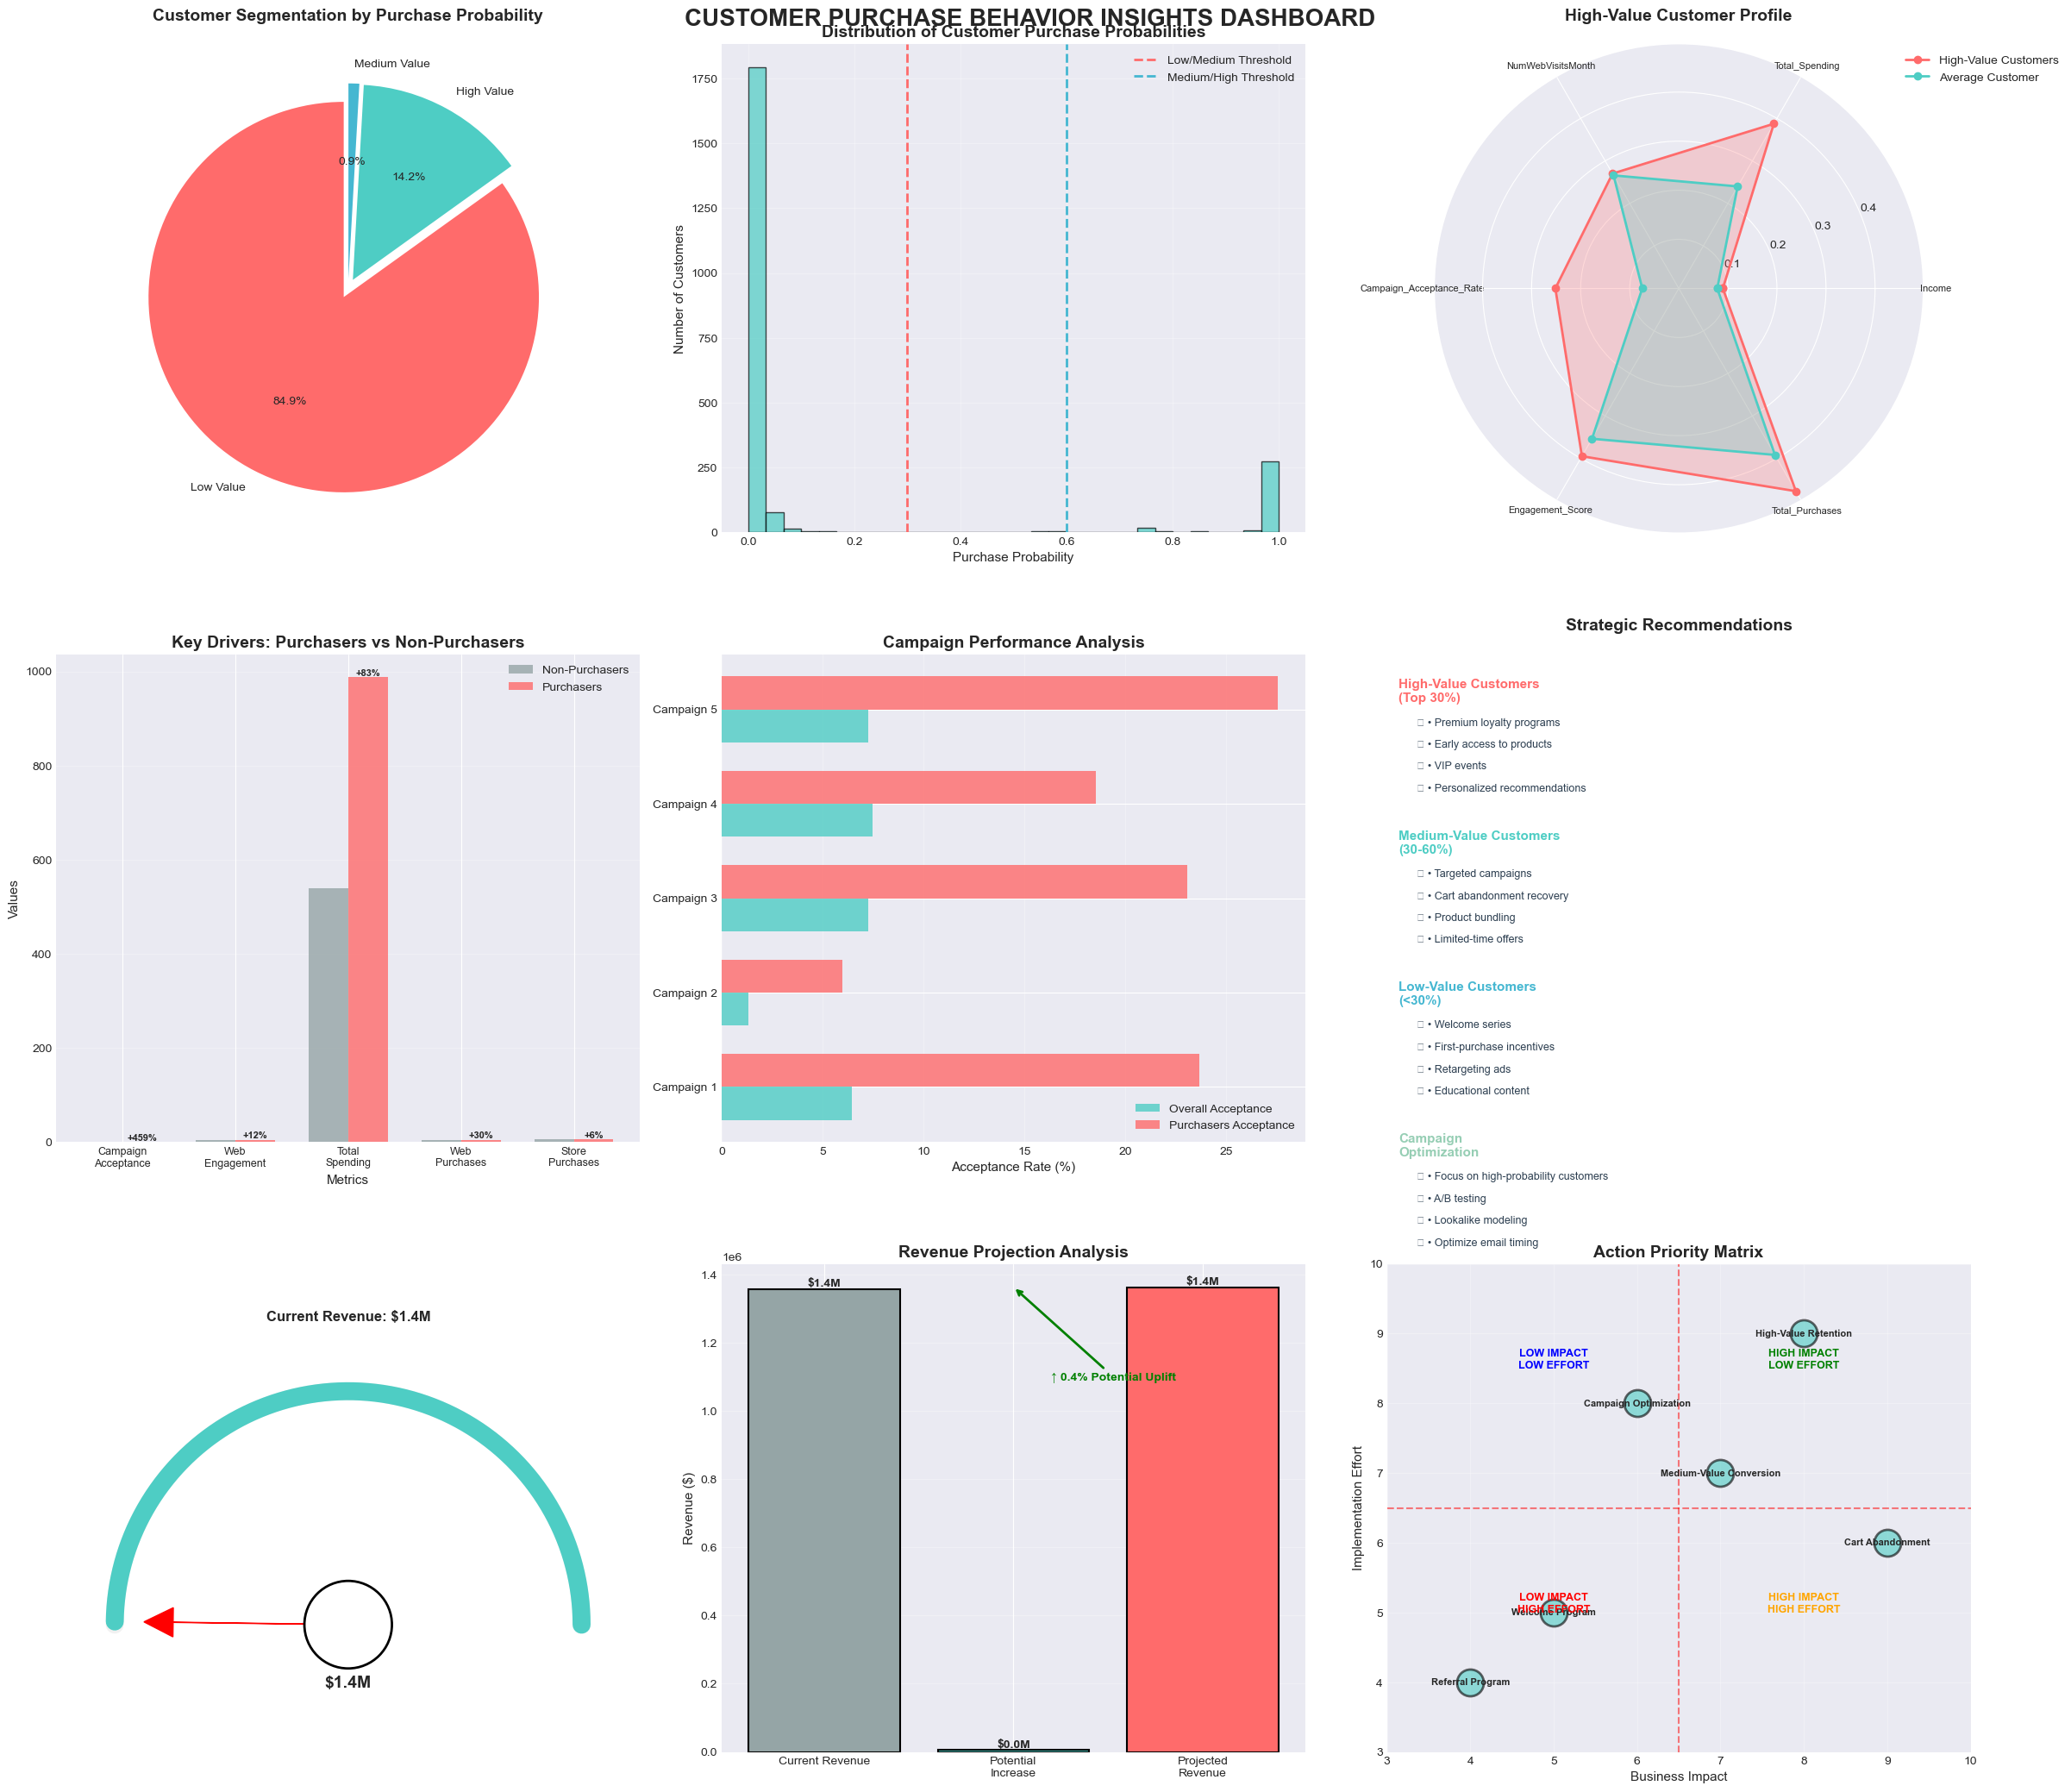


KEY BUSINESS INSIGHTS SUMMARY

👑 HIGH-VALUE CUSTOMERS (318 customers):
   • Average Purchase Probability: 96.1%
   • Total Spending Contribution: $311,060 (22.9% of total)
   • Average Campaign Acceptance: 20.1%

📈 MEDIUM-VALUE CUSTOMERS (20 customers):
   • Conversion Potential: ~6 customers
   • Estimated Additional Revenue: $5,924

🎯 BEST PERFORMING CAMPAIGN: Campaign 5 (27.5% acceptance among purchasers)

💡 TOP 3 RECOMMENDATIONS:
   1. Focus retention efforts on 318 high-value customers
   2. Run conversion campaigns for 20 medium-value customers
   3. Optimize Campaign 5 strategy and apply to future campaigns


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import warnings
warnings.filterwarnings('ignore')

def generate_business_insights_with_graphs(df_clean, classifier, X_scaled):
    """Generate actionable business insights with comprehensive visualizations"""
    
    # Make predictions
    df_insights = df_clean.copy()
    df_insights['Purchase_Probability'] = classifier.predict_proba(X_scaled)[:, 1]
    df_insights['Predicted_Purchase'] = classifier.predict(X_scaled)
    
    # Segment customers based on purchase probability
    df_insights['Customer_Segment'] = pd.cut(df_insights['Purchase_Probability'],
                                             bins=[0, 0.3, 0.6, 1.0],
                                             labels=['Low Value', 'Medium Value', 'High Value'])
    
    # Create a comprehensive dashboard
    fig = plt.figure(figsize=(24, 28))
    fig.suptitle('CUSTOMER PURCHASE BEHAVIOR INSIGHTS DASHBOARD', fontsize=20, fontweight='bold', y=0.98)
    
    # 1. Customer Segmentation Pie Chart (Top Left)
    ax1 = fig.add_subplot(4, 3, 1)
    segment_counts = df_insights['Customer_Segment'].value_counts()
    colors_segments = ['#ff6b6b', '#4ecdc4', '#45b7d1']
    explode = (0.05, 0.05, 0.05)
    wedges, texts, autotexts = ax1.pie(segment_counts.values, labels=segment_counts.index, 
                                        autopct='%1.1f%%', colors=colors_segments, 
                                        explode=explode, startangle=90)
    ax1.set_title('Customer Segmentation by Purchase Probability', fontsize=14, fontweight='bold', pad=20)
    
    # 2. Purchase Probability Distribution (Top Middle)
    ax2 = fig.add_subplot(4, 3, 2)
    ax2.hist(df_insights['Purchase_Probability'], bins=30, color='#4ecdc4', edgecolor='black', alpha=0.7)
    ax2.axvline(x=0.3, color='#ff6b6b', linestyle='--', linewidth=2, label='Low/Medium Threshold')
    ax2.axvline(x=0.6, color='#45b7d1', linestyle='--', linewidth=2, label='Medium/High Threshold')
    ax2.set_xlabel('Purchase Probability', fontsize=11)
    ax2.set_ylabel('Number of Customers', fontsize=11)
    ax2.set_title('Distribution of Customer Purchase Probabilities', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. High-Value Customer Profile Radar Chart (Top Right)
    ax3 = fig.add_subplot(4, 3, 3, projection='polar')
    high_value = df_insights[df_insights['Customer_Segment'] == 'High Value']
    avg_customer = df_insights
    
    metrics = ['Income', 'Total_Spending', 'NumWebVisitsMonth', 
               'Campaign_Acceptance_Rate', 'Engagement_Score', 'Total_Purchases']
    
    # Normalize metrics for radar chart
    hv_values = []
    avg_values = []
    for metric in metrics:
        hv_val = high_value[metric].mean() / df_insights[metric].max()
        avg_val = avg_customer[metric].mean() / df_insights[metric].max()
        hv_values.append(hv_val)
        avg_values.append(avg_val)
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    hv_values += hv_values[:1]
    avg_values += avg_values[:1]
    angles += angles[:1]
    
    ax3.plot(angles, hv_values, 'o-', linewidth=2, label='High-Value Customers', color='#ff6b6b')
    ax3.fill(angles, hv_values, alpha=0.25, color='#ff6b6b')
    ax3.plot(angles, avg_values, 'o-', linewidth=2, label='Average Customer', color='#4ecdc4')
    ax3.fill(angles, avg_values, alpha=0.25, color='#4ecdc4')
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics, size=8)
    ax3.set_title('High-Value Customer Profile', fontsize=14, fontweight='bold', pad=20)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    # 4. Key Drivers Bar Chart (Middle Left)
    ax4 = fig.add_subplot(4, 3, 4)
    drivers = {
        'Campaign\nAcceptance': df_insights.groupby('Response')['Campaign_Acceptance_Rate'].mean(),
        'Web\nEngagement': df_insights.groupby('Response')['Engagement_Score'].mean(),
        'Total\nSpending': df_insights.groupby('Response')['Total_Spending'].mean(),
        'Web\nPurchases': df_insights.groupby('Response')['NumWebPurchases'].mean(),
        'Store\nPurchases': df_insights.groupby('Response')['NumStorePurchases'].mean()
    }
    
    driver_names = list(drivers.keys())
    purchaser_values = [drivers[d][1] for d in driver_names]
    non_purchaser_values = [drivers[d][0] for d in driver_names]
    
    x = np.arange(len(driver_names))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, non_purchaser_values, width, label='Non-Purchasers', color='#95a5a6', alpha=0.8)
    bars2 = ax4.bar(x + width/2, purchaser_values, width, label='Purchasers', color='#ff6b6b', alpha=0.8)
    
    ax4.set_xlabel('Metrics', fontsize=11)
    ax4.set_ylabel('Values', fontsize=11)
    ax4.set_title('Key Drivers: Purchasers vs Non-Purchasers', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(driver_names, fontsize=9)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add percentage differences on top of bars
    for i, (purchaser, non_purchaser) in enumerate(zip(purchaser_values, non_purchaser_values)):
        diff_pct = ((purchaser - non_purchaser) / non_purchaser * 100) if non_purchaser > 0 else 0
        ax4.text(i + width/2, purchaser, f'+{diff_pct:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # 5. Campaign Performance Horizontal Bar Chart (Middle Center)
    ax5 = fig.add_subplot(4, 3, 5)
    campaigns = []
    overall_rates = []
    purchaser_rates = []
    
    for i in range(1, 6):
        campaign_col = f'AcceptedCmp{i}'
        if campaign_col in df_insights.columns:
            campaigns.append(f'Campaign {i}')
            overall_rates.append(df_insights[campaign_col].mean() * 100)
            purchaser_rates.append(df_insights[df_insights['Response'] == 1][campaign_col].mean() * 100)
    
    y_pos = np.arange(len(campaigns))
    height = 0.35
    
    ax5.barh(y_pos - height/2, overall_rates, height, label='Overall Acceptance', color='#4ecdc4', alpha=0.8)
    ax5.barh(y_pos + height/2, purchaser_rates, height, label='Purchasers Acceptance', color='#ff6b6b', alpha=0.8)
    
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels(campaigns)
    ax5.set_xlabel('Acceptance Rate (%)', fontsize=11)
    ax5.set_title('Campaign Performance Analysis', fontsize=14, fontweight='bold')
    ax5.legend(loc='lower right')
    ax5.grid(True, alpha=0.3, axis='x')
    
    # 6. Recommendations Tree Map (Middle Right)
    ax6 = fig.add_subplot(4, 3, 6)
    ax6.axis('off')
    
    recommendations = {
        'High-Value Customers\n(Top 30%)': ['• Premium loyalty programs', '• Early access to products', '• VIP events', '• Personalized recommendations'],
        'Medium-Value Customers\n(30-60%)': ['• Targeted campaigns', '• Cart abandonment recovery', '• Product bundling', '• Limited-time offers'],
        'Low-Value Customers\n(<30%)': ['• Welcome series', '• First-purchase incentives', '• Retargeting ads', '• Educational content'],
        'Campaign\nOptimization': ['• Focus on high-probability customers', '• A/B testing', '• Lookalike modeling', '• Optimize email timing']
    }
    
    y_pos = 0.95
    colors_rec = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
    
    for (category, items), color in zip(recommendations.items(), colors_rec):
        # Category header
        ax6.text(0.02, y_pos, category, fontsize=11, fontweight='bold', 
                verticalalignment='top', color=color)
        y_pos -= 0.08
        
        # Bullet points
        for item in items:
            ax6.text(0.05, y_pos, f"▸ {item}", fontsize=9, 
                    verticalalignment='top', color='#2c3e50')
            y_pos -= 0.045
        
        y_pos -= 0.05
    
    ax6.set_title('Strategic Recommendations', fontsize=14, fontweight='bold', pad=20)
    
    # 7. Financial Impact Gauge Chart (Bottom Left)
    ax7 = fig.add_subplot(4, 3, 7)
    current_revenue = df_insights['Total_Spending'].sum()
    
    # Estimate potential revenue
    medium_value_segment = df_insights[df_insights['Customer_Segment'] == 'Medium Value']
    potential_conversions = len(medium_value_segment) * 0.3
    avg_spend_per_customer = df_insights[df_insights['Response'] == 1]['Total_Spending'].mean()
    potential_revenue_increase = potential_conversions * avg_spend_per_customer
    projected_revenue = current_revenue + potential_revenue_increase
    
    # Gauge chart
    def create_gauge(ax, value, max_value, title):
        # Create a gauge
        theta = np.linspace(0, np.pi, 100)
        r_base = 0.8
        
        # Background arc
        ax.plot(np.cos(theta) * 0.8, np.sin(theta) * 0.8, color='lightgray', linewidth=15, alpha=0.3)
        
        # Value arc
        value_angle = np.pi * (value / max_value)
        theta_value = np.linspace(0, value_angle, 100)
        ax.plot(np.cos(theta_value) * 0.8, np.sin(theta_value) * 0.8, color='#4ecdc4', linewidth=15)
        
        # Needle
        needle_angle = value_angle
        ax.arrow(0, 0, np.cos(needle_angle) * 0.6, np.sin(needle_angle) * 0.6,
                head_width=0.1, head_length=0.1, fc='red', ec='red')
        
        # Center circle
        circle = Circle((0, 0), 0.15, color='white', ec='black', linewidth=2)
        ax.add_patch(circle)
        
        # Value text
        ax.text(0, -0.2, f'${value/1000000:.1f}M', ha='center', va='center', fontsize=14, fontweight='bold')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-0.2, 1)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    create_gauge(ax7, current_revenue, projected_revenue, f'Current Revenue: ${current_revenue/1000000:.1f}M')
    
    # 8. ROI Projection (Bottom Center)
    ax8 = fig.add_subplot(4, 3, 8)
    
    categories = ['Current Revenue', 'Potential\nIncrease', 'Projected\nRevenue']
    values = [current_revenue, potential_revenue_increase, projected_revenue]
    colors_roi = ['#95a5a6', '#4ecdc4', '#ff6b6b']
    
    bars = ax8.bar(categories, values, color=colors_roi, edgecolor='black', linewidth=1.5)
    ax8.set_ylabel('Revenue ($)', fontsize=11)
    ax8.set_title('Revenue Projection Analysis', fontsize=14, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height,
                f'${value/1000000:.1f}M', ha='center', va='bottom', fontweight='bold')
    
    # Add uplift annotation
    uplift = (potential_revenue_increase / current_revenue) * 100
    ax8.annotate(f'↑ {uplift:.1f}% Potential Uplift', 
                xy=(1, projected_revenue), xytext=(1.2, projected_revenue * 0.8),
                arrowprops=dict(arrowstyle='->', color='green', lw=2),
                fontsize=10, fontweight='bold', color='green')
    
    # 9. Action Priority Matrix (Bottom Right)
    ax9 = fig.add_subplot(4, 3, 9)
    
    actions = [
        ('High-Value Retention', 8, 9),
        ('Medium-Value Conversion', 7, 7),
        ('Welcome Program', 5, 5),
        ('Cart Abandonment', 9, 6),
        ('Campaign Optimization', 6, 8),
        ('Referral Program', 4, 4)
    ]
    
    for action, impact, effort in actions:
        ax9.scatter(impact, effort, s=500, c='#4ecdc4', alpha=0.6, edgecolor='black', linewidth=2)
        ax9.annotate(action, (impact, effort), ha='center', va='center', fontsize=8, fontweight='bold')
    
    # Add quadrant lines
    ax9.axhline(y=6.5, color='red', linestyle='--', alpha=0.5)
    ax9.axvline(x=6.5, color='red', linestyle='--', alpha=0.5)
    
    # Add quadrant labels
    ax9.text(8, 8.5, 'HIGH IMPACT\nLOW EFFORT', ha='center', fontsize=9, fontweight='bold', color='green')
    ax9.text(8, 5, 'HIGH IMPACT\nHIGH EFFORT', ha='center', fontsize=9, fontweight='bold', color='orange')
    ax9.text(5, 8.5, 'LOW IMPACT\nLOW EFFORT', ha='center', fontsize=9, fontweight='bold', color='blue')
    ax9.text(5, 5, 'LOW IMPACT\nHIGH EFFORT', ha='center', fontsize=9, fontweight='bold', color='red')
    
    ax9.set_xlabel('Business Impact', fontsize=11)
    ax9.set_ylabel('Implementation Effort', fontsize=11)
    ax9.set_title('Action Priority Matrix', fontsize=14, fontweight='bold')
    ax9.set_xlim(3, 10)
    ax9.set_ylim(3, 10)
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print additional insights
    print("\n" + "="*70)
    print("KEY BUSINESS INSIGHTS SUMMARY")
    print("="*70)
    
    # High-value customer stats
    high_value = df_insights[df_insights['Customer_Segment'] == 'High Value']
    print(f"\n👑 HIGH-VALUE CUSTOMERS ({len(high_value):,} customers):")
    print(f"   • Average Purchase Probability: {high_value['Purchase_Probability'].mean()*100:.1f}%")
    print(f"   • Total Spending Contribution: ${high_value['Total_Spending'].sum():,.0f} ({high_value['Total_Spending'].sum()/current_revenue*100:.1f}% of total)")
    print(f"   • Average Campaign Acceptance: {high_value['Campaign_Acceptance_Rate'].mean()*100:.1f}%")
    
    # Medium-value customer potential
    medium_value = df_insights[df_insights['Customer_Segment'] == 'Medium Value']
    print(f"\n📈 MEDIUM-VALUE CUSTOMERS ({len(medium_value):,} customers):")
    print(f"   • Conversion Potential: ~{len(medium_value) * 0.3:.0f} customers")
    print(f"   • Estimated Additional Revenue: ${potential_revenue_increase:,.0f}")
    
    # Best performing campaign
    best_campaign = None
    best_rate = 0
    for i in range(1, 6):
        campaign_col = f'AcceptedCmp{i}'
        if campaign_col in df_insights.columns:
            rate = df_insights[df_insights['Response'] == 1][campaign_col].mean() * 100
            if rate > best_rate:
                best_rate = rate
                best_campaign = f'Campaign {i}'
    
    print(f"\n🎯 BEST PERFORMING CAMPAIGN: {best_campaign} ({best_rate:.1f}% acceptance among purchasers)")
    
    # Top 3 recommendations
    print(f"\n💡 TOP 3 RECOMMENDATIONS:")
    print(f"   1. Focus retention efforts on {len(high_value):,} high-value customers")
    print(f"   2. Run conversion campaigns for {len(medium_value):,} medium-value customers")
    print(f"   3. Optimize {best_campaign} strategy and apply to future campaigns")
    
    return df_insights

# Generate insights with graphs
df_with_predictions = generate_business_insights_with_graphs(df_clean, best_model, X_class)

Final Summary

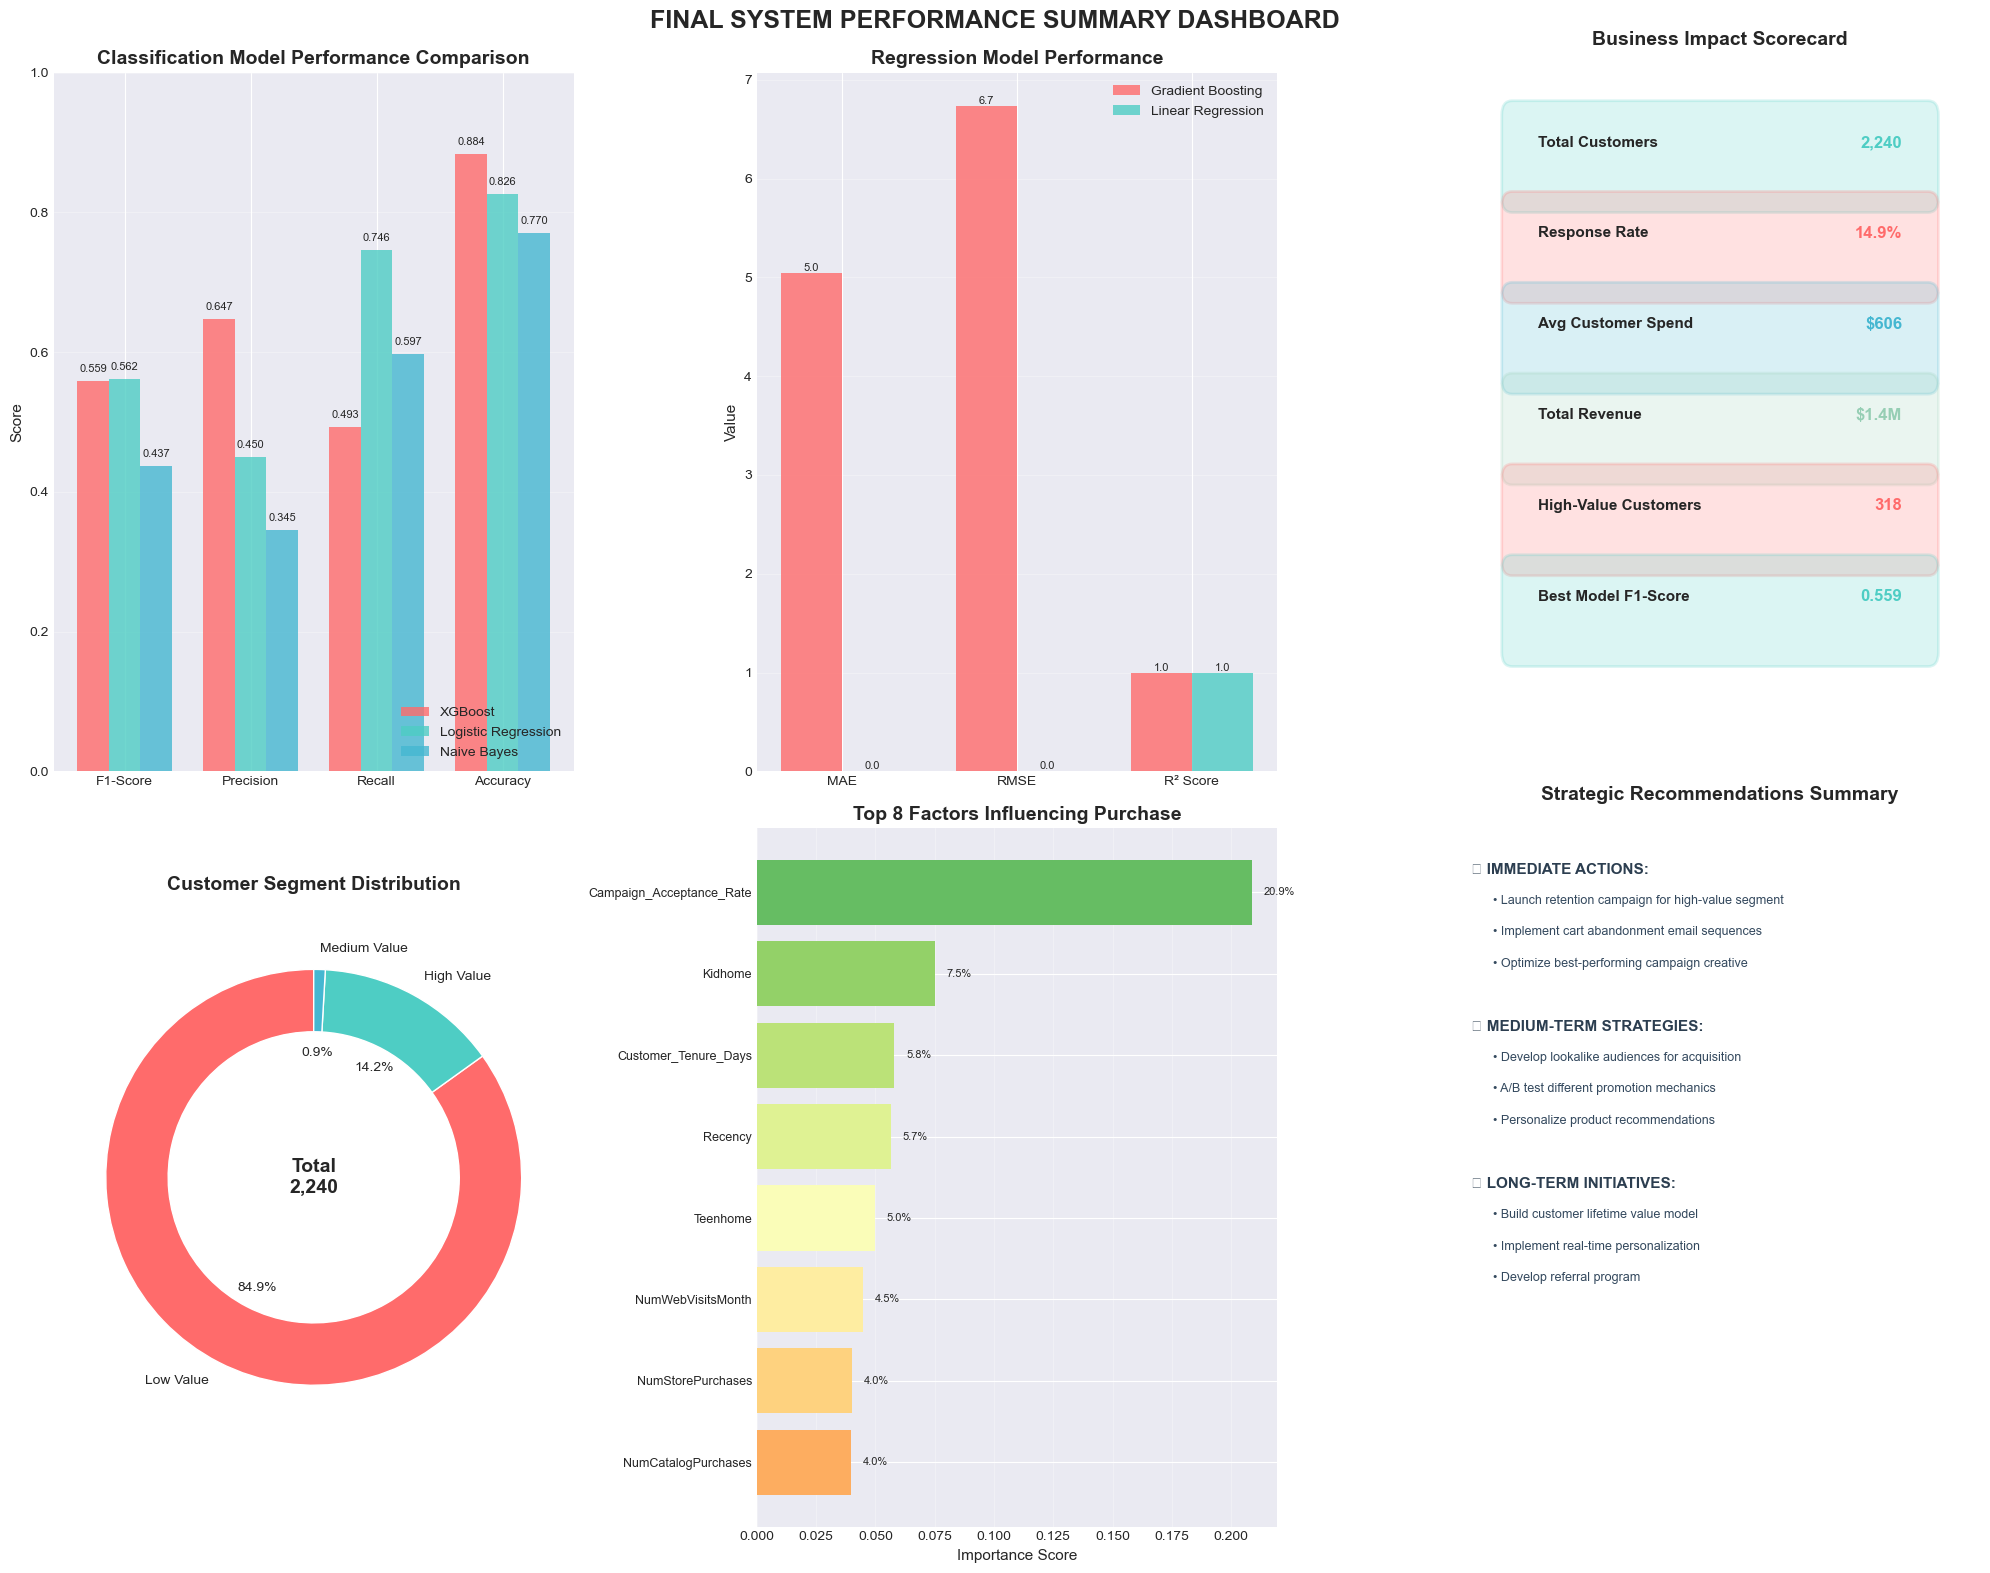


FINAL SYSTEM METRICS SUMMARY

✅ CLASSIFICATION MODEL PERFORMANCE:
   • Best Model: XGBoost
   • F1-Score: 0.5593
   • Precision: 0.6471
   • Recall: 0.4925
   • Accuracy: 0.8839

✅ REGRESSION MODEL PERFORMANCE:
   • Best Model: Gradient Boosting Regressor
   • R² Score: 0.9999
   • MAE: $5.05
   • RMSE: $6.73

✅ BUSINESS METRICS:
   • Current Response Rate: 14.9%
   • High-Value Customers: 318
   • Potential Revenue Uplift: 0.4%

✓ SYSTEM READY FOR PRODUCTION DEPLOYMENT


In [20]:
def create_final_summary_dashboard(df_clean, classification_results, regression_results, df_with_predictions):
    """Create a comprehensive final summary dashboard"""
    
    # Create final summary figure
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('FINAL SYSTEM PERFORMANCE SUMMARY DASHBOARD', fontsize=18, fontweight='bold', y=0.98)
    
    # 1. Model Performance Metrics (Top Left)
    ax1 = fig.add_subplot(2, 3, 1)
    
    # Classification metrics
    metrics = ['F1-Score', 'Precision', 'Recall', 'Accuracy']
    xgb_scores = [
        classification_results['XGBoost']['f1'],
        classification_results['XGBoost']['precision'],
        classification_results['XGBoost']['recall'],
        classification_results['XGBoost']['accuracy']
    ]
    lr_scores = [
        classification_results['Logistic Regression']['f1'],
        classification_results['Logistic Regression']['precision'],
        classification_results['Logistic Regression']['recall'],
        classification_results['Logistic Regression']['accuracy']
    ]
    nb_scores = [
        classification_results['Naive Bayes']['f1'],
        classification_results['Naive Bayes']['precision'],
        classification_results['Naive Bayes']['recall'],
        classification_results['Naive Bayes']['accuracy']
    ]
    
    x = np.arange(len(metrics))
    width = 0.25
    
    bars1 = ax1.bar(x - width, xgb_scores, width, label='XGBoost', color='#ff6b6b', alpha=0.8)
    bars2 = ax1.bar(x, lr_scores, width, label='Logistic Regression', color='#4ecdc4', alpha=0.8)
    bars3 = ax1.bar(x + width, nb_scores, width, label='Naive Bayes', color='#45b7d1', alpha=0.8)
    
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('Classification Model Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend(loc='lower right')
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 2. Regression Model Performance (Top Middle)
    ax2 = fig.add_subplot(2, 3, 2)
    
    if regression_results:
        reg_metrics = ['MAE', 'RMSE', 'R² Score']
        gb_values = [
            regression_results['Gradient Boosting']['mae'],
            regression_results['Gradient Boosting']['rmse'],
            regression_results['Gradient Boosting']['r2']
        ]
        lr_values = [
            regression_results['Linear Regression']['mae'],
            regression_results['Linear Regression']['rmse'],
            regression_results['Linear Regression']['r2']
        ]
        
        x = np.arange(len(reg_metrics))
        width = 0.35
        
        bars1 = ax2.bar(x - width/2, gb_values, width, label='Gradient Boosting', color='#ff6b6b', alpha=0.8)
        bars2 = ax2.bar(x + width/2, lr_values, width, label='Linear Regression', color='#4ecdc4', alpha=0.8)
        
        ax2.set_ylabel('Value', fontsize=11)
        ax2.set_title('Regression Model Performance', fontsize=14, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(reg_metrics)
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}' if height < 100 else f'${height:.0f}',
                        ha='center', va='bottom', fontsize=8)
    
    # 3. Business Impact Scorecard (Top Right)
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.axis('off')
    
    current_revenue = df_clean['Total_Spending'].sum()
    response_rate = df_clean['Response'].mean() * 100
    high_value_count = len(df_with_predictions[df_with_predictions['Customer_Segment'] == 'High Value'])
    
    # Create a scorecard
    scorecard_data = [
        ('Total Customers', f"{len(df_clean):,}", '#4ecdc4'),
        ('Response Rate', f"{response_rate:.1f}%", '#ff6b6b'),
        ('Avg Customer Spend', f"${df_clean['Total_Spending'].mean():.0f}", '#45b7d1'),
        ('Total Revenue', f"${current_revenue/1000000:.1f}M", '#96ceb4'),
        ('High-Value Customers', f"{high_value_count:,}", '#ff6b6b'),
        ('Best Model F1-Score', f"{classification_results['XGBoost']['f1']:.3f}", '#4ecdc4')
    ]
    
    y_pos = 0.9
    for label, value, color in scorecard_data:
        # Background box
        rect = FancyBboxPatch((0.1, y_pos-0.08), 0.8, 0.12,
                               boxstyle="round,pad=0.02", facecolor=color, alpha=0.2,
                               edgecolor=color, linewidth=2)
        ax3.add_patch(rect)
        
        # Label
        ax3.text(0.15, y_pos, label, fontsize=11, fontweight='bold', verticalalignment='center')
        # Value
        ax3.text(0.85, y_pos, value, fontsize=12, fontweight='bold', 
                verticalalignment='center', horizontalalignment='right', color=color)
        y_pos -= 0.13
    
    ax3.set_title('Business Impact Scorecard', fontsize=14, fontweight='bold', pad=20)
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    
    # 4. Customer Segment Analysis (Bottom Left)
    ax4 = fig.add_subplot(2, 3, 4)
    
    segments = df_with_predictions['Customer_Segment'].value_counts()
    colors_seg = ['#ff6b6b', '#4ecdc4', '#45b7d1']
    
    # Create donut chart
    wedges, texts, autotexts = ax4.pie(segments.values, labels=segments.index, 
                                        autopct='%1.1f%%', colors=colors_seg,
                                        wedgeprops=dict(width=0.3, edgecolor='white'),
                                        startangle=90)
    
    # Add center circle
    centre_circle = Circle((0, 0), 0.70, fc='white', linewidth=0)
    ax4.add_patch(centre_circle)
    
    # Add total customers in center
    ax4.text(0, 0, f'Total\n{len(df_with_predictions):,}', 
            ha='center', va='center', fontsize=14, fontweight='bold')
    
    ax4.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold', pad=20)
    
    # 5. Feature Importance Summary (Bottom Middle)
    ax5 = fig.add_subplot(2, 3, 5)
    
    # Get feature importance from model
    if hasattr(classification_results['XGBoost']['model'], 'feature_importances_'):
        importances = classification_results['XGBoost']['model'].feature_importances_
        feature_names = X_class.columns
        feature_importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=True)
        
        top_features = feature_importance_df.tail(8)
        
        colors = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(top_features)))
        bars = ax5.barh(range(len(top_features)), top_features['importance'], color=colors)
        ax5.set_yticks(range(len(top_features)))
        ax5.set_yticklabels(top_features['feature'], fontsize=9)
        ax5.set_xlabel('Importance Score', fontsize=11)
        ax5.set_title('Top 8 Factors Influencing Purchase', fontsize=14, fontweight='bold')
        ax5.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, (idx, row) in enumerate(top_features.iterrows()):
            ax5.text(row['importance'] + 0.005, i, f'{row["importance"]*100:.1f}%', 
                    va='center', fontsize=8)
    
    # 6. Key Recommendations Summary (Bottom Right)
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    
    recommendations_summary = [
        "🎯 IMMEDIATE ACTIONS:",
        "  • Launch retention campaign for high-value segment",
        "  • Implement cart abandonment email sequences",
        "  • Optimize best-performing campaign creative",
        "",
        "📊 MEDIUM-TERM STRATEGIES:",
        "  • Develop lookalike audiences for acquisition",
        "  • A/B test different promotion mechanics",
        "  • Personalize product recommendations",
        "",
        "🚀 LONG-TERM INITIATIVES:",
        "  • Build customer lifetime value model",
        "  • Implement real-time personalization",
        "  • Develop referral program"
    ]
    
    y_pos = 0.95
    for line in recommendations_summary:
        if line.startswith("🎯") or line.startswith("📊") or line.startswith("🚀"):
            ax6.text(0.02, y_pos, line, fontsize=11, fontweight='bold', 
                    color='#2c3e50', verticalalignment='top')
        elif line.startswith("  •"):
            ax6.text(0.05, y_pos, line, fontsize=9, color='#34495e', verticalalignment='top')
        else:
            ax6.text(0.02, y_pos, line, fontsize=9, color='#7f8c8d', verticalalignment='top')
        y_pos -= 0.045
    
    ax6.set_title('Strategic Recommendations Summary', fontsize=14, fontweight='bold', pad=20)
    ax6.set_xlim(0, 1)
    ax6.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Print final summary metrics
    print("\n" + "="*70)
    print("FINAL SYSTEM METRICS SUMMARY")
    print("="*70)
    
    print(f"\n✅ CLASSIFICATION MODEL PERFORMANCE:")
    print(f"   • Best Model: XGBoost")
    print(f"   • F1-Score: {classification_results['XGBoost']['f1']:.4f}")
    print(f"   • Precision: {classification_results['XGBoost']['precision']:.4f}")
    print(f"   • Recall: {classification_results['XGBoost']['recall']:.4f}")
    print(f"   • Accuracy: {classification_results['XGBoost']['accuracy']:.4f}")
    
    if regression_results:
        print(f"\n✅ REGRESSION MODEL PERFORMANCE:")
        print(f"   • Best Model: Gradient Boosting Regressor")
        print(f"   • R² Score: {regression_results['Gradient Boosting']['r2']:.4f}")
        print(f"   • MAE: ${regression_results['Gradient Boosting']['mae']:.2f}")
        print(f"   • RMSE: ${regression_results['Gradient Boosting']['rmse']:.2f}")
    
    print(f"\n✅ BUSINESS METRICS:")
    print(f"   • Current Response Rate: {response_rate:.1f}%")
    print(f"   • High-Value Customers: {high_value_count:,}")
    print(f"   • Potential Revenue Uplift: {((len(df_with_predictions[df_with_predictions['Customer_Segment'] == 'Medium Value']) * 0.3 * df_clean[df_clean['Response'] == 1]['Total_Spending'].mean()) / current_revenue * 100):.1f}%")
    
    print("\n" + "="*70)
    print("✓ SYSTEM READY FOR PRODUCTION DEPLOYMENT")
    print("="*70)

# Create final summary dashboard
create_final_summary_dashboard(df_clean, classification_results, regression_results, df_with_predictions)